In [1]:
!pip install pandas_datareader yfinance scikit-learn matplotlib numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf

In [3]:
company = 'AAPL'
df = yf.download(company, start='2015-01-01', end='2024-01-01')

# Fix multi-level columns
df.columns = df.columns.get_level_values(0).str.lower()
print(df.columns.tolist())  # should show ['close', 'high', 'low', 'open', 'volume']
print(df.head())

/tmp/ipykernel_871/1006605074.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

['close', 'high', 'low', 'open', 'volume']
Price           close       high        low       open     volume
Date                                                             
2015-01-02  24.192604  24.659506  23.754468  24.648441  212818400
2015-01-05  23.511055  24.042129  23.325180  23.962467  257142000
2015-01-06  23.513268  23.772165  23.152579  23.575226  263188400
2015-01-07  23.842983  23.942559  23.610638  23.721278  160423600
2015-01-08  24.759085  24.816618  24.053199  24.170479  237458000


In [4]:
df.columns = df.columns.get_level_values(0).str.lower()

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df.to_csv(f'/content/drive/MyDrive/{company}.csv')
print("Saved to Drive!")

Mounted at /content/drive
Saved to Drive!


In [6]:
df1 = df['close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
df1 = scaler.fit_transform(df1)

print("Scaled data shape:", df1.shape)
print("Sample values:", df1[:5])

Scaled data shape: (2264, 1)
Sample values: [[0.02068558]
 [0.01679827]
 [0.01681089]
 [0.01869147]
 [0.02391658]]


In [7]:
training_size = int(len(df1) * 0.70)
test_size = len(df1) - training_size

train_data = df1[0:training_size]
test_data = df1[training_size:]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 1584
Test size: 680


In [8]:
timespan = int(input('Enter time span in days (e.g. 5, 10, 30): '))
print(f"Using timespan: {timespan} days")

Enter time span in days (e.g. 5, 10, 30): 30
Using timespan: 30 days


In [9]:
df1

array([[0.02068558],
       [0.01679827],
       [0.01681089],
       ...,
       [0.97202637],
       [0.97445148],
       [0.96852966]])

In [10]:
def create_dataset(dataset, span=1):
    x, y = [], []
    for i in range(len(dataset) - span):
        a = dataset[i:(i + span), 0]
        x.append(a)
        y.append(dataset[i + span, 0])
    return np.array(x), np.array(y)

In [11]:
x_train, y_train = create_dataset(train_data, timespan)
x_test, y_test = create_dataset(test_data, timespan)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1554, 30)
y_train shape: (1554,)
x_test shape: (650, 30)
y_test shape: (650,)


In [12]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Model trained successfully!")
print(f"Model coefficient (first): {model.coef_[0]:.4f}")
print(f"Model intercept: {model.intercept_:.4f}")

Model trained successfully!
Model coefficient (first): -0.0089
Model intercept: 0.0001


In [13]:
train_predict = model.predict(x_train).reshape(-1, 1)
test_predict = model.predict(x_test).reshape(-1, 1)

# Inverse transform back to real prices
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

Train RMSE: 1.2165
Test RMSE:  2.7248


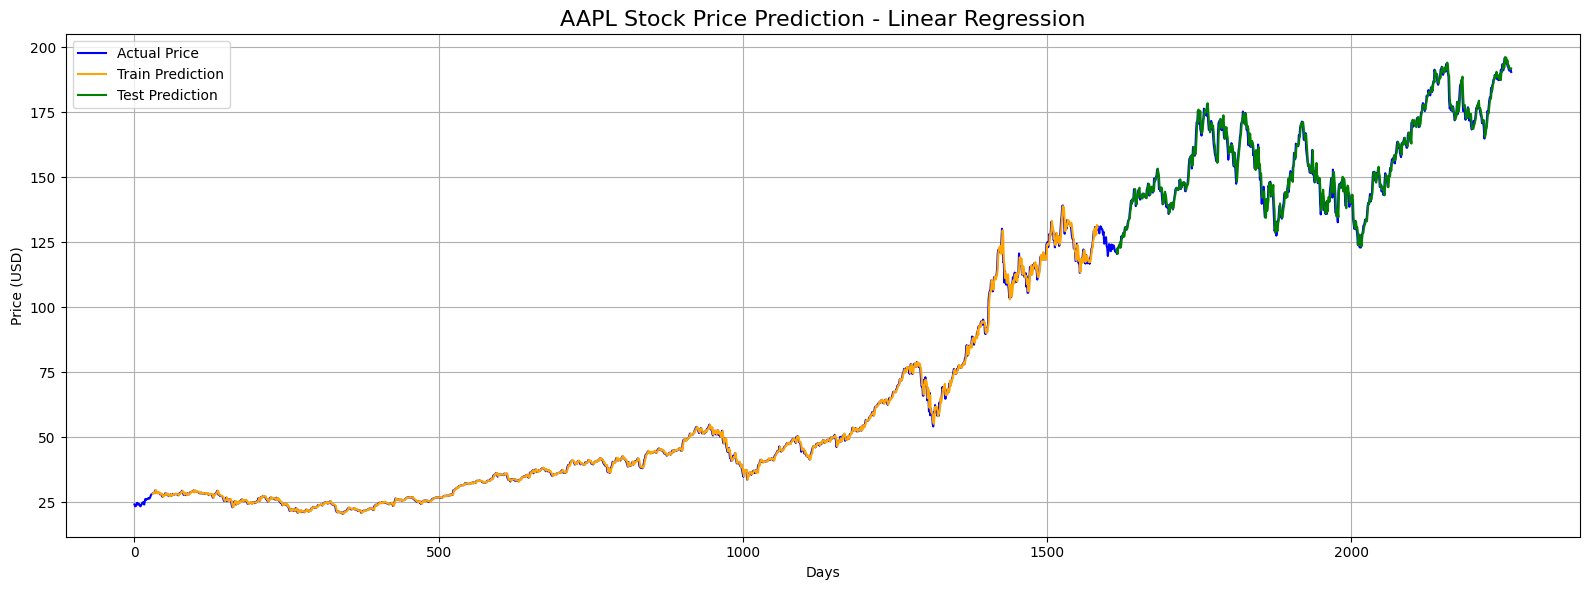

In [14]:
actual_prices = scaler.inverse_transform(df1)

train_plot = np.empty_like(actual_prices)
train_plot[:] = np.nan
train_plot[timespan:len(train_predict) + timespan] = train_predict

test_plot = np.empty_like(actual_prices)
test_plot[:] = np.nan

# Fix: calculate exact start index and clip to fit
test_start = len(train_predict) + (timespan * 2)
test_end = test_start + len(test_predict)
test_end = min(test_end, len(actual_prices))  # prevent overflow
test_predict_trimmed = test_predict[:test_end - test_start]

test_plot[test_start:test_end] = test_predict_trimmed

plt.figure(figsize=(16, 6))
plt.plot(actual_prices, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(train_plot, label='Train Prediction', color='orange', linewidth=1.5)
plt.plot(test_plot, label='Test Prediction', color='green', linewidth=1.5)
plt.title(f'{company} Stock Price Prediction - Linear Regression', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
l = len(test_data)
x_input = test_data[l - timespan:].reshape(1, -1)
temp_input = list(x_input[0])

print(f"Last {timespan} scaled values used as input:")
print(temp_input)

Last 30 scaled values used as input:
[np.float64(0.9526256916727474), np.float64(0.9525128130214968), np.float64(0.9624388237635497), np.float64(0.9578705890649002), np.float64(0.9616492824187954), np.float64(0.9540918086804335), np.float64(0.9530767711248926), np.float64(0.9565169155556072), np.float64(0.9507080600600586), np.float64(0.9539790170597544), np.float64(0.9612545117464184), np.float64(0.951046434922096), np.float64(0.9735493205838768), np.float64(0.9673456073853794), np.float64(0.9783431385238845), np.float64(0.9864646573962137), np.float64(0.9721957341051553), np.float64(0.9808244671482547), np.float64(0.9991537147226202), np.float64(1.0), np.float64(0.9969544521805194), np.float64(0.9874795208906118), np.float64(0.9934012550374112), np.float64(0.9815013039029012), np.float64(0.9806552797172359), np.float64(0.9745644451699893), np.float64(0.9714625015401692), np.float64(0.9720263726129934), np.float64(0.9744514794881671), np.float64(0.9685296583107963)]


In [16]:
lst_output = []
n_steps = timespan
i = 1

while i <= 30:
    x_input = np.array(temp_input[-timespan:]).reshape(1, n_steps)
    yhat = model.predict(x_input)
    temp_input.append(yhat[0])
    lst_output.append(yhat[0])
    i += 1

print("30 days of scaled predictions done!")

30 days of scaled predictions done!


In [17]:
lst_output_arr = np.array(lst_output).reshape(-1, 1)
forecast = scaler.inverse_transform(lst_output_arr)

print(f"\n{company} Predicted Prices for Next 30 Days:\n")
for day, price in enumerate(forecast, 1):
    print(f"Day {day:2d}: ${price[0]:.2f}")


AAPL Predicted Prices for Next 30 Days:

Day  1: $191.03
Day  2: $191.53
Day  3: $191.47
Day  4: $192.15
Day  5: $191.96
Day  6: $192.27
Day  7: $192.86
Day  8: $193.23
Day  9: $192.96
Day 10: $193.08
Day 11: $193.37
Day 12: $193.39
Day 13: $193.67
Day 14: $193.73
Day 15: $193.83
Day 16: $194.51
Day 17: $195.03
Day 18: $195.46
Day 19: $195.68
Day 20: $196.44
Day 21: $196.59
Day 22: $197.08
Day 23: $197.32
Day 24: $197.59
Day 25: $197.98
Day 26: $198.34
Day 27: $198.53
Day 28: $198.76
Day 29: $199.16
Day 30: $199.37


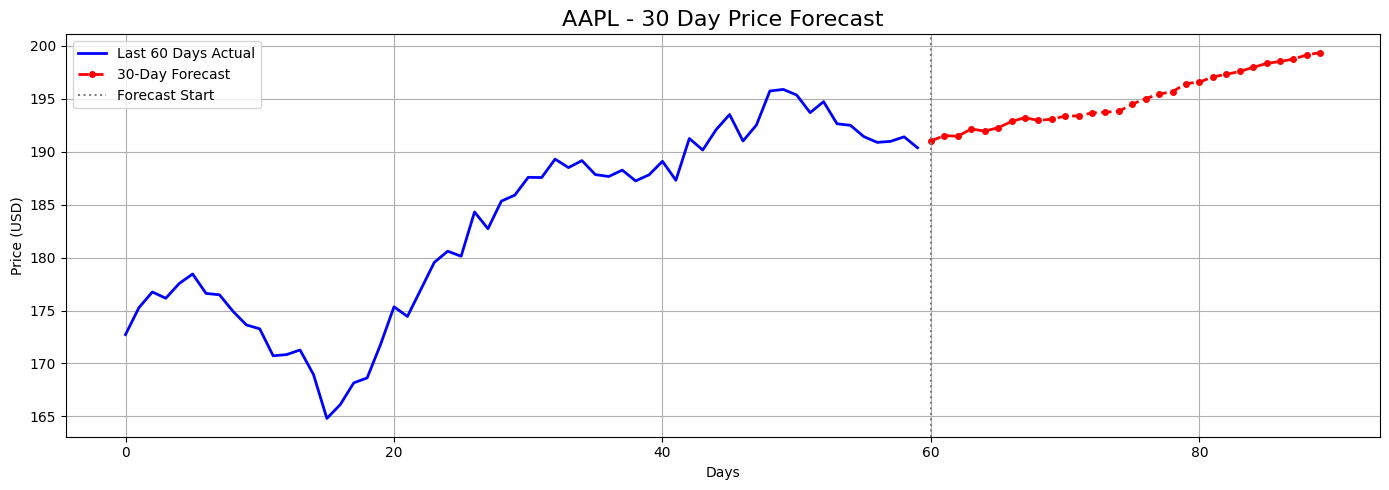

In [18]:
plt.figure(figsize=(14, 5))

# Show last 60 days of actual + 30 day forecast
last_60 = scaler.inverse_transform(df1[-60:])

plt.plot(range(60), last_60, label='Last 60 Days Actual', color='blue', linewidth=2)
plt.plot(range(60, 90), forecast, label='30-Day Forecast', color='red',
         linewidth=2, linestyle='--', marker='o', markersize=4)

plt.axvline(x=60, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title(f'{company} - 30 Day Price Forecast', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
print("=" * 40)
print(f"   STOCK PREDICTION SUMMARY: {company}")
print("=" * 40)
print(f"Total data points     : {len(df)}")
print(f"Training size         : {training_size}")
print(f"Test size             : {test_size}")
print(f"Timespan used         : {timespan} days")
print(f"Train RMSE            : ${train_rmse:.2f}")
print(f"Test RMSE             : ${test_rmse:.2f}")
print(f"Last actual price     : ${actual_prices[-1][0]:.2f}")
print(f"Day 1 forecast        : ${forecast[0][0]:.2f}")
print(f"Day 30 forecast       : ${forecast[29][0]:.2f}")
print("=" * 40)

   STOCK PREDICTION SUMMARY: AAPL
Total data points     : 2264
Training size         : 1584
Test size             : 680
Timespan used         : 30 days
Train RMSE            : $1.22
Test RMSE             : $2.72
Last actual price     : $190.38
Day 1 forecast        : $191.03
Day 30 forecast       : $199.37
